# unsupervised /machine Learning

**TYPES (1=Clustring , 2=Associate)**

**K-Mean Clustring**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ds = pd.read_csv("unsuper.csv.xlsx")
ds.head(10)

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


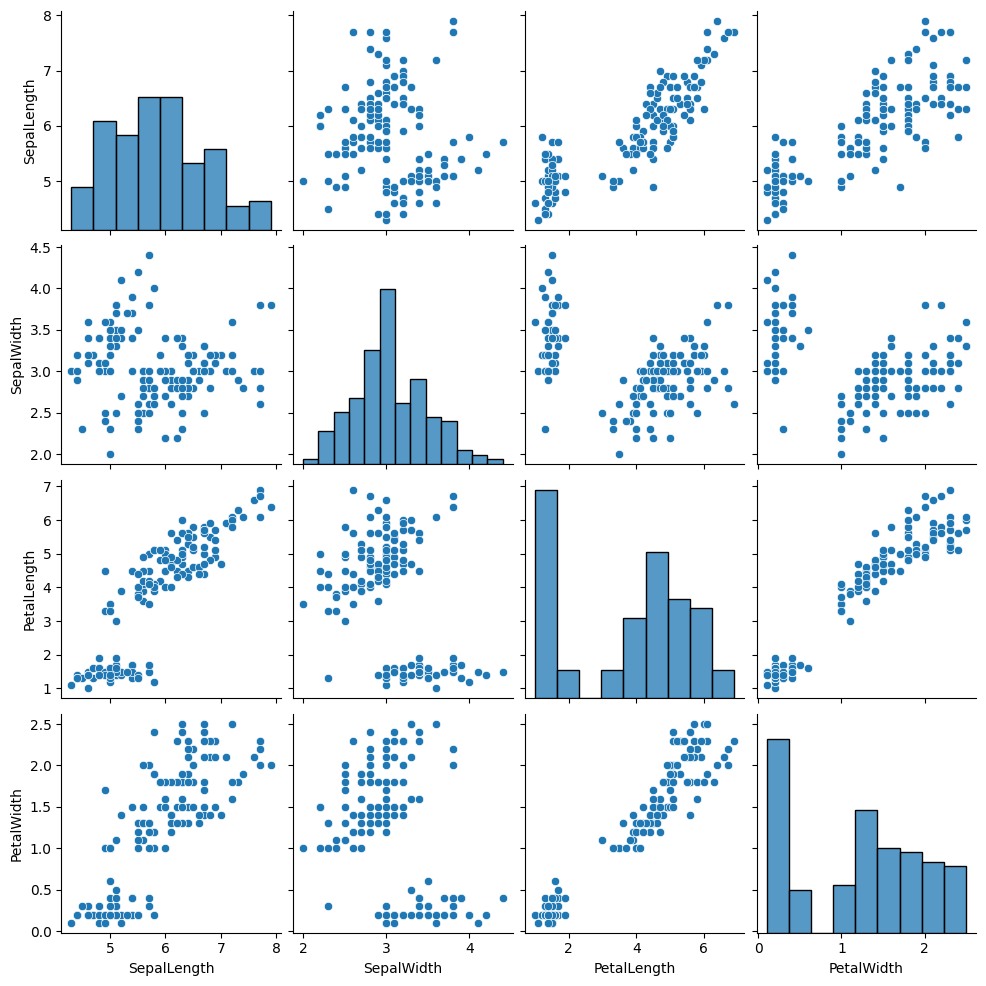

In [4]:
sns.pairplot(data=ds)
plt.show()

In [5]:
from sklearn.cluster import KMeans

In [6]:
wcss=[]

for i in range(2,21):
    km=KMeans(n_clusters=i,init='k-means++') #har iteration mn in cluster bnata hy
    km.fit(ds)
    wcss.append(km.inertia_) #center point chose karta hy 

AttributeError: module 'matplotlib.pyplot' has no attribute 'xlable'

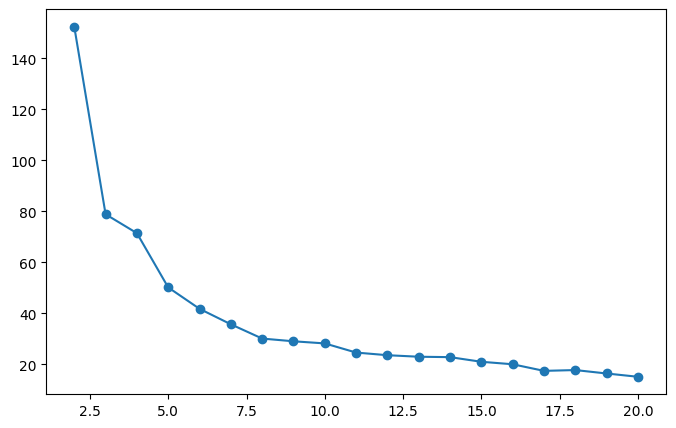

In [7]:
plt.figure(figsize=(8,5))
plt.plot([i for i  in range(2,21)],wcss,marker='o')
plt.xlable("no of cluster")
plt.xticks([i for i  in range(2,21)])
plt.ylable("WCSS")
plt.grid(axis= "x")
plt.show()

In [8]:
kmn=KMeans(n_clusters=3)
ds["Predict"]=kmn.fit_predict(ds)

In [9]:
ds

,SepalLength,SepalWidth,PetalLength,PetalWidth,Predict
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0


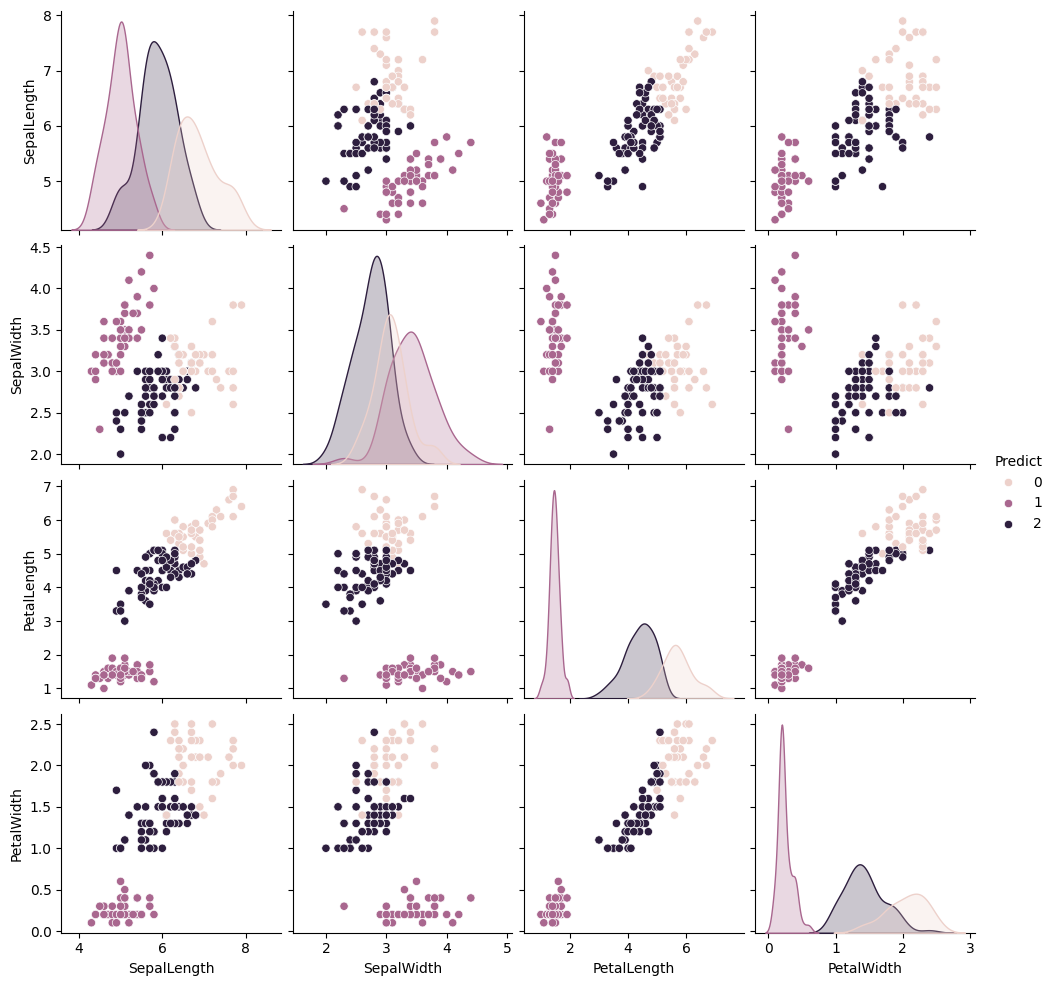

In [17]:
sns.pairplot(data=ds,hue="Predict")
plt.savefig("Prediction.jpg")
plt.show()


In [11]:
org_ds=pd.read_csv("ds_org.csv.xlsx")
org_ds.head(10)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


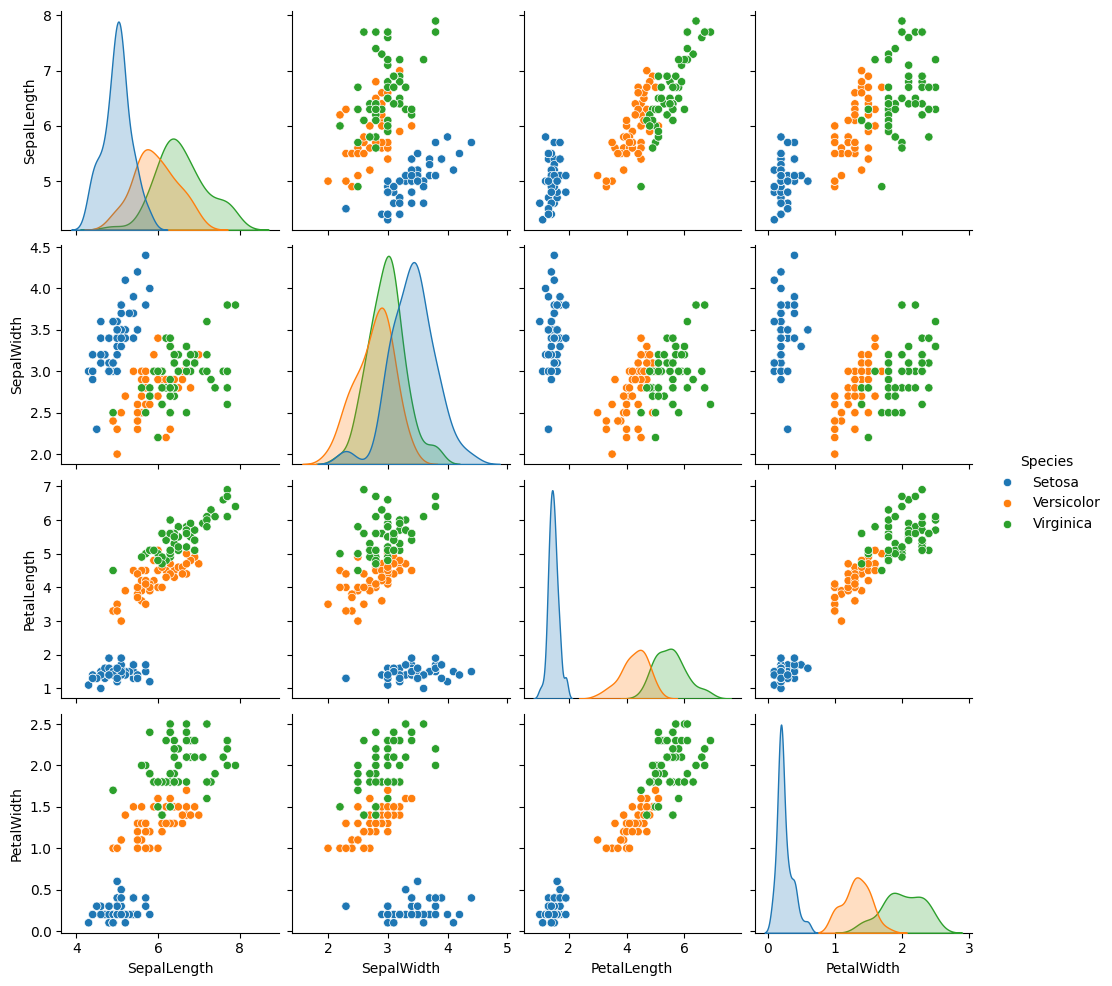

In [16]:
sns.pairplot(data=org_ds,hue="Species")
plt.savefig("original.jpg")
plt.show()

# Herarical clustring

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
ds= pd.read_csv("unsuper.csv.xlsx")
ds.head(2)

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


In [3]:
import scipy.cluster.hierarchy as sc

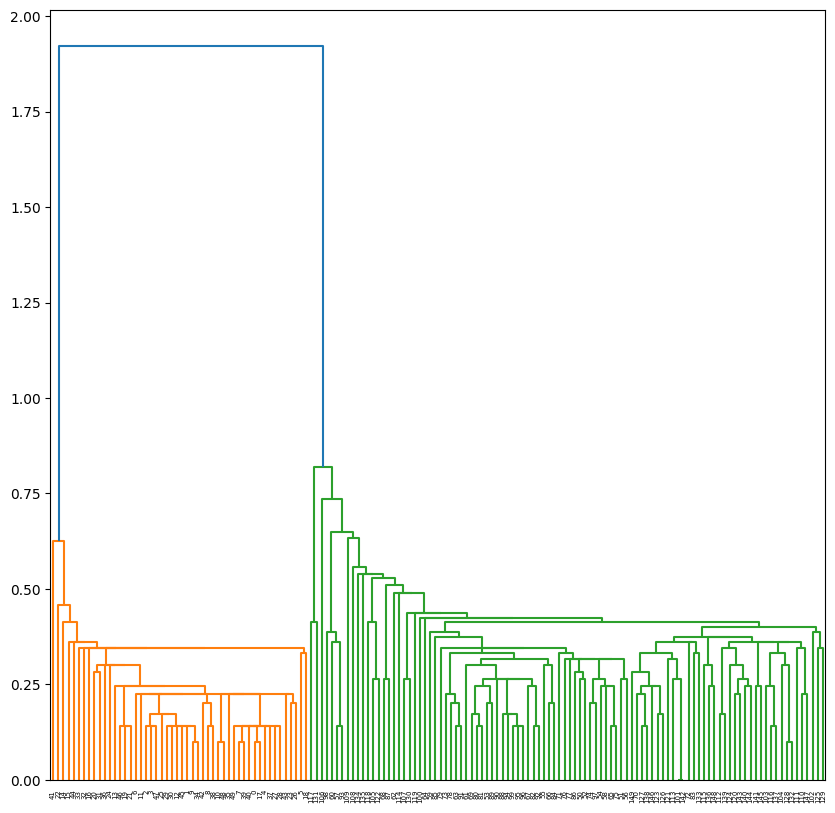

In [16]:
plt.figure(figsize=(10,10))
sc.dendrogram(sc.linkage(ds,method='single',metric='euclidean')) #euclidean distance(used to find distance beyween 2 data points )
plt.savefig("herarical cluster.jpg")
plt.show()

In [17]:
from sklearn.cluster import AgglomerativeClustering #agglomerative(butom to up uproach )

In [18]:
ac=AgglomerativeClustering(n_clusters=2,linkage='single') #linkage(link between points of clustring)
ds['predict']=ac.fit_predict(ds)
ds.head(2)

,SepalLength,SepalWidth,PetalLength,PetalWidth,predict
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1


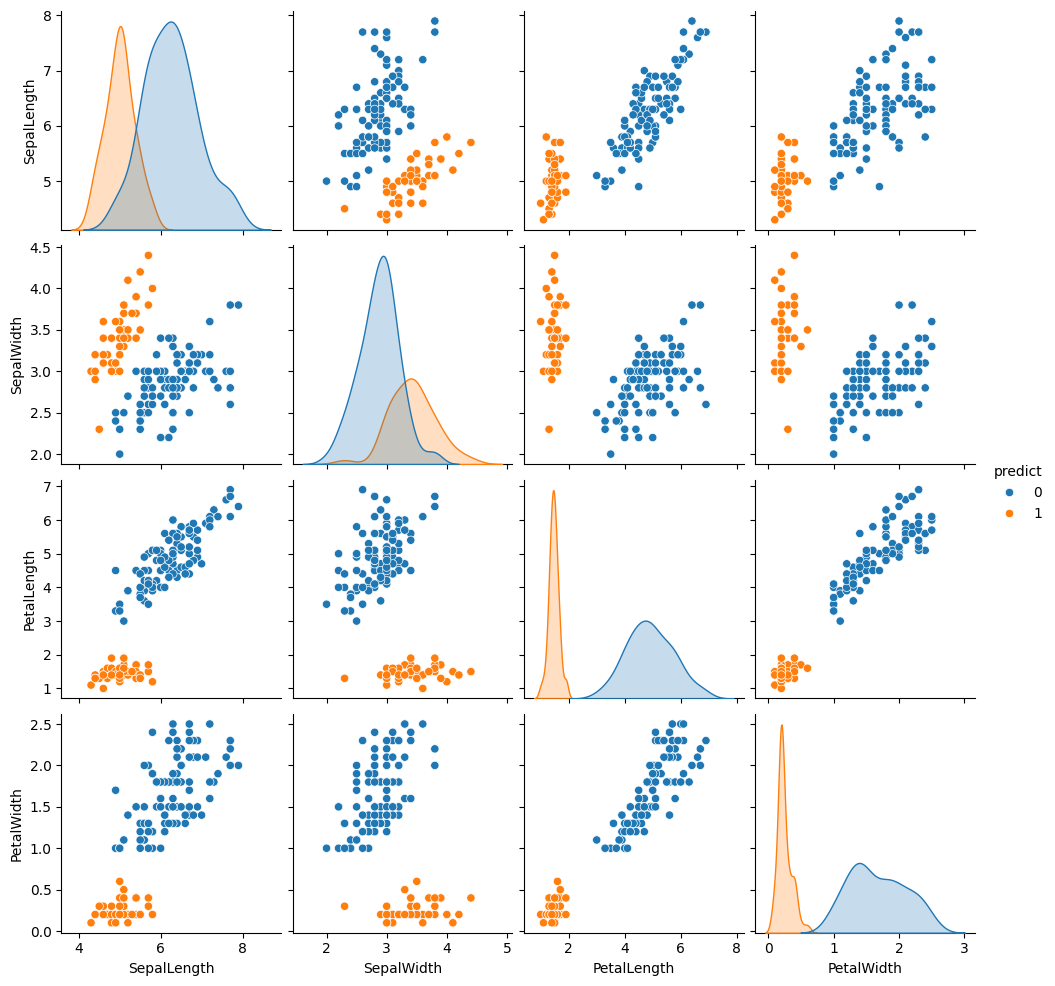

In [15]:
sns.pairplot(data=ds,hue="predict")

# DBSCAN clustring

it is used to clustering in non linear saperable data. it is try to find 2 center points . it is also used to detect outlier . it is special case of non linear data set and outlier detection .  

we need 4 things in DBSCAN 
minimun point = 4 (must 4 point exist in circle)no of points >= min point
epn (radius) = (center of circle)
a) core point (the circle which exsist min point and radius is called core point)
b) binary point (the end of the circle)
c) noise point (outlier point)

jab no of oints min point sy kam ana lag jayn whan par clustering hona band o jati hy or wo binary point hota hy .

jhan hmary pass no of point one any lag jay wo noise point ban jata hy jisy hm outlier bhi khty hn 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons

In [11]:
x,y = make_moons(n_samples=250 , noise= 0.05)

In [12]:
df={'data1':x[:,0] , 'data2':x[:,1]}

In [13]:
ds= pd.DataFrame(df)
ds.head(3)

,data1,data2
0,0.208393,-0.184048
1,0.027311,0.225079
2,0.511323,0.843132


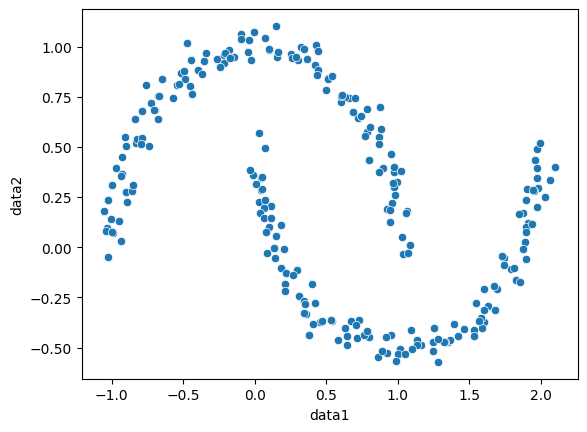

In [24]:
sns.scatterplot(x='data1',y='data2', data=ds)
plt.show()


In [15]:
from sklearn.cluster import DBSCAN

In [21]:
db=DBSCAN(eps=0.3,min_samples=5)
ds["predict"]=db.fit_predict(ds)

In [22]:
db.fit_predict(ds)

array([0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 0])

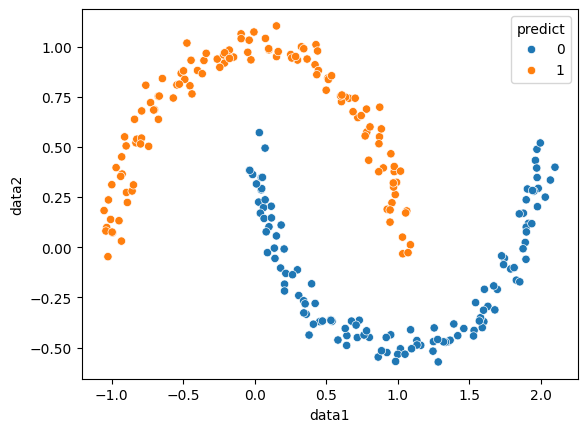

In [23]:
sns.scatterplot(x='data1',y='data2', data=ds,hue="predict" )
plt.show()

**Practices**

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [28]:
x,y = make_moons(n_samples=150,noise=0.03)

In [29]:
df= {'data1':x[:,0] ,'data2':x[:,1]}

In [30]:
ds=pd.DataFrame(df)
ds.head(2)

,data1,data2
0,2.005655,0.325148
1,-1.000946,0.406676


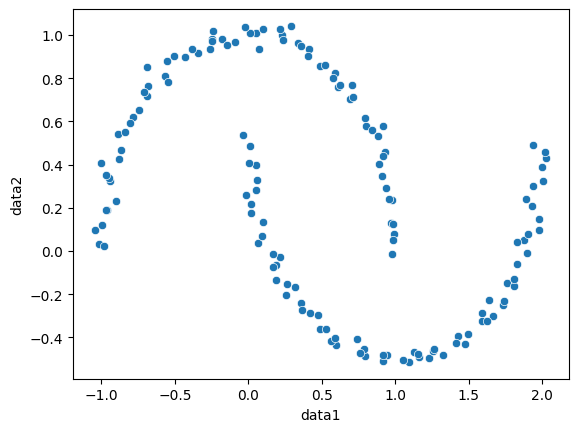

In [31]:
sns.scatterplot(x='data1',y='data2',data=ds)
plt.show()

In [33]:
from sklearn.cluster import DBSCAN

In [38]:
db = DBSCAN(eps=0.2,min_samples=4)
ds["predict"]=db.fit_predict(ds)

In [39]:
ds.head(3)

,data1,data2,predict
0,2.005655,0.325148,0
1,-1.000946,0.406676,1
2,0.058643,0.329205,0


In [40]:
db.fit_predict(ds)

array([0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0])

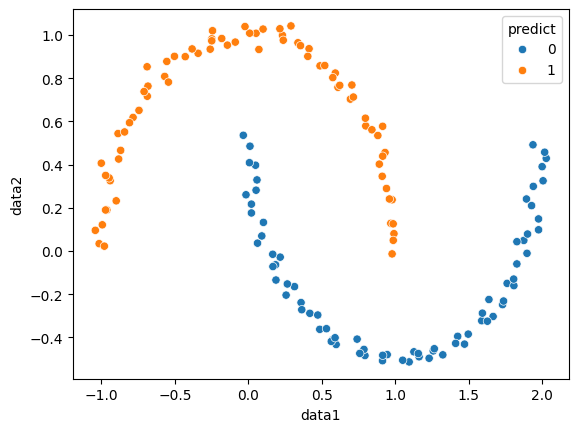

In [41]:
sns.scatterplot(x="data1",y="data2",data=ds,hue="predict")
plt.show()

# silhout clustring

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
ds = pd.read_csv("unsuper.csv.xlsx")
ds.head(10)

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


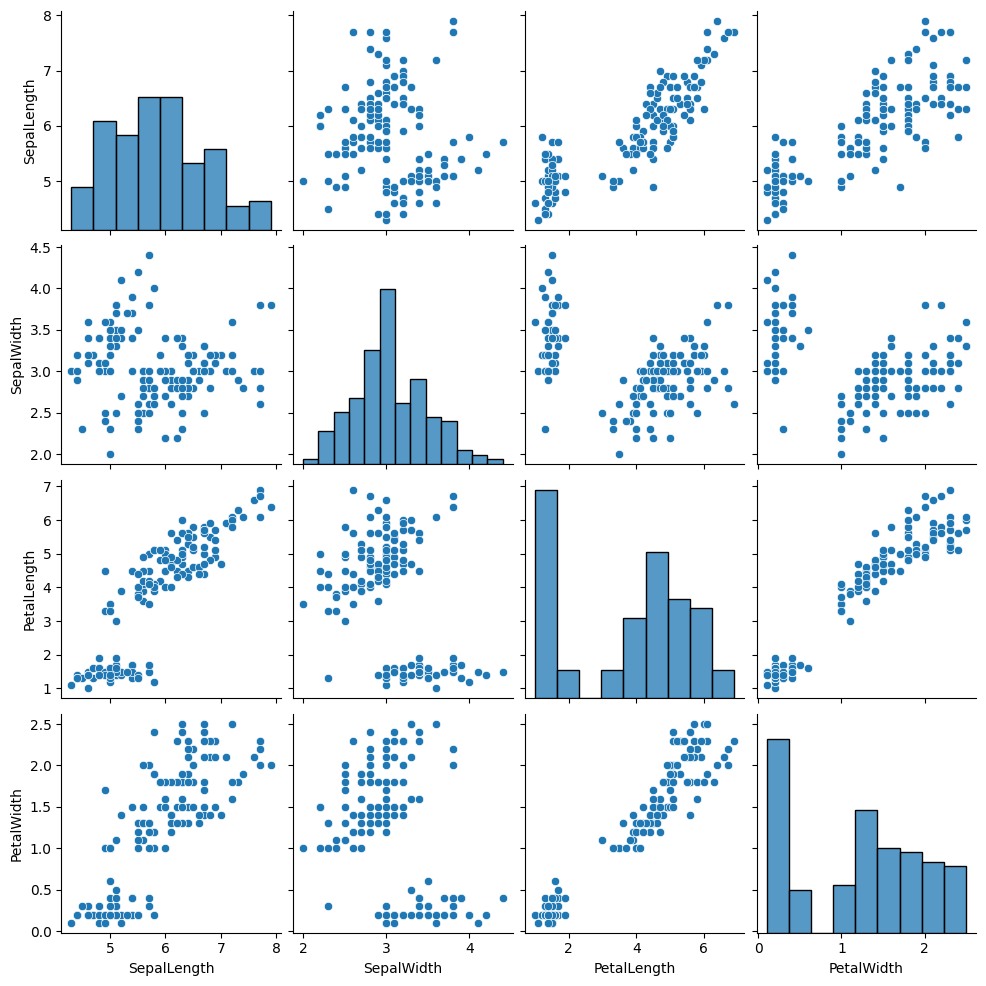

In [4]:
sns.pairplot(data=ds)
plt.show()

In [5]:
from sklearn.cluster import KMeans


In [6]:
wcss=[]

for i in range(2,21):
    km=KMeans(n_clusters=i,init='k-means++') #har iteration mn in cluster bnata hy
    km.fit(ds)
    wcss.append(km.inertia_) #center point chose karta hy 

AttributeError: module 'matplotlib.pyplot' has no attribute 'xlable'

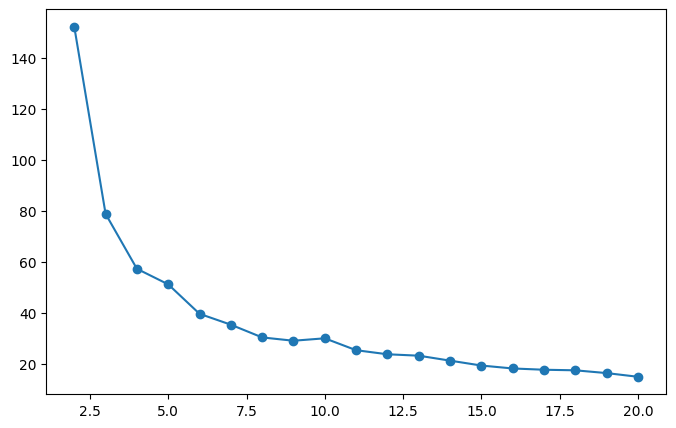

In [7]:
plt.figure(figsize=(8,5))
plt.plot([i for i  in range(2,21)],wcss,marker='o')
plt.xlable("no of cluster")
plt.xticks([i for i  in range(2,21)])
plt.ylable("WCSS")
plt.grid(axis= "x")
plt.show()

In [8]:
from sklearn.metrics import silhouette_score

In [9]:
kmn=KMeans(n_clusters=3)
ds["Predict"]=kmn.fit_predict(ds)

In [10]:
kmn.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2], dtype=int32)

In [11]:
silhouette_score(ds,labels=kmn.labels_)

0.6220342112834246

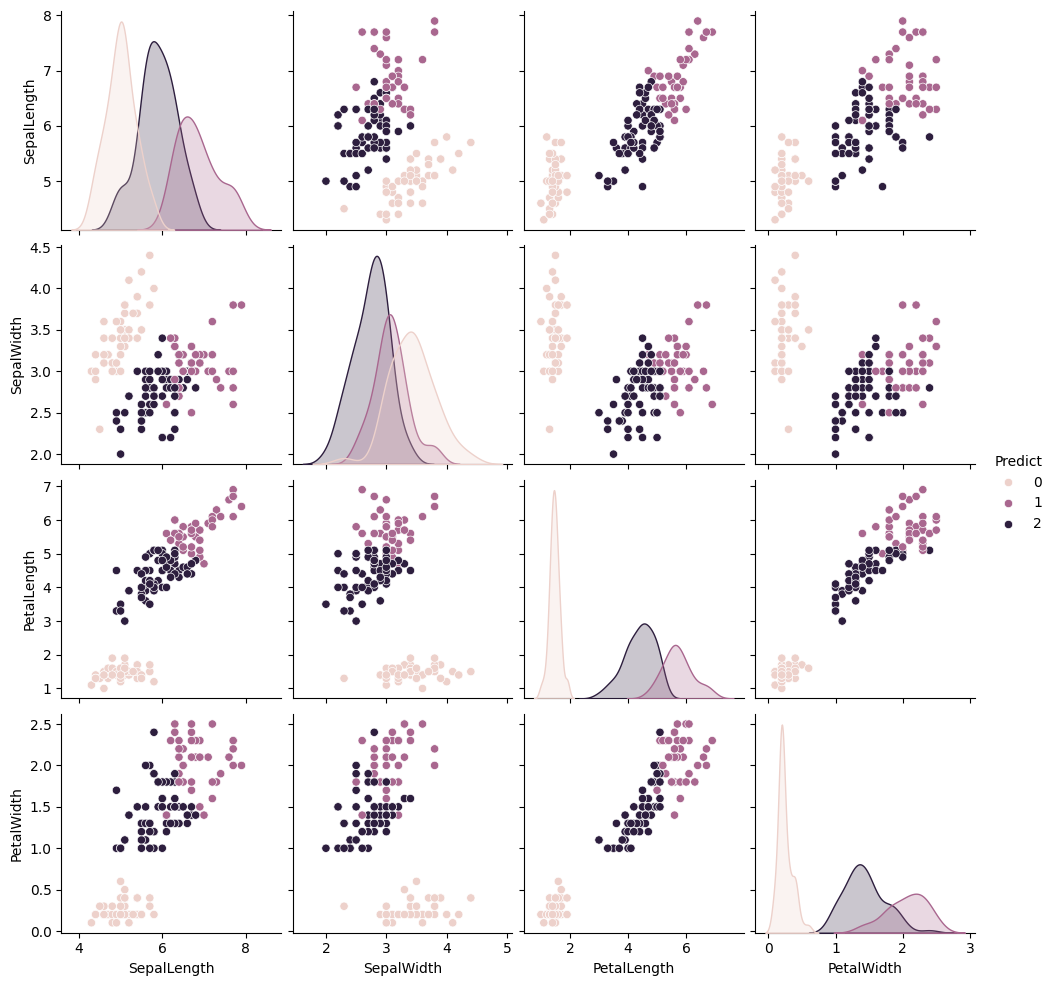

In [12]:
sns.pairplot(data=ds,hue="Predict")
plt.savefig("Prediction.jpg")
plt.show()

In [13]:
org_ds=pd.read_csv("ds_org.csv.xlsx")
org_ds.head(10)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


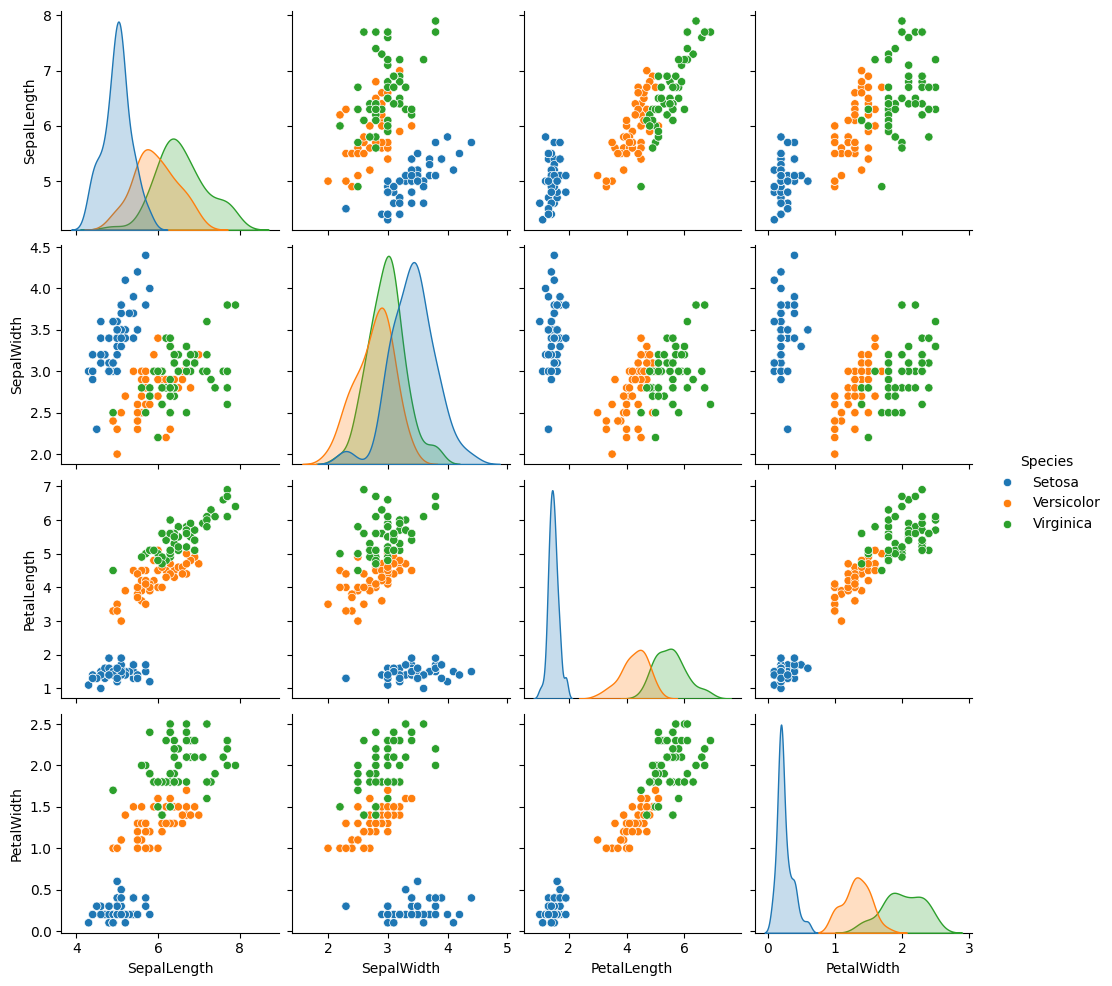

In [14]:
sns.pairplot(data=org_ds,hue="Species")
plt.savefig("original.jpg")
plt.show()

In [15]:
ss=[]
no_c=[j for j in range(2,21)]
for i in range(2,21):
    km1=KMeans(n_clusters=i)
    km1.fit(ds)
    ss.append(silhouette_score(ds,km1.labels_))

AttributeError: module 'matplotlib.pyplot' has no attribute 'xlable'

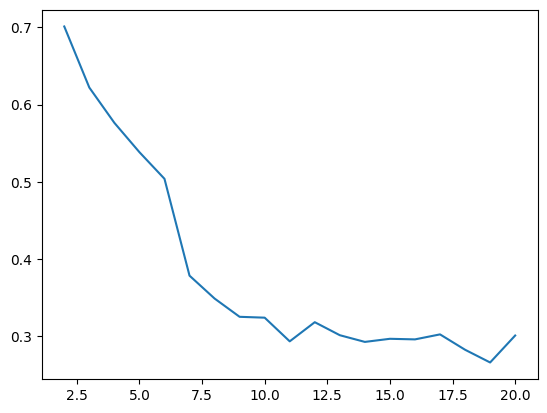

In [16]:
plt.plot(no_c,ss)
plt.xlable("no of cluster")
plt.ylable("silhouetts_score")
plt.xticks(n0_c)
plt.grid(axis="x")
plt.show()

# Association Rule Learning

In [2]:
import pandas as pd
import numpy as np

In [3]:
ds= pd.read_excel("grocessori.csv.xlsx")
ds.head(3)

,item 1,item 2,item 3,item 4,item 5,item 6,item 7,item 8,item 9
0,Flour,5kg,NaN,Rice,10kg,NaN,Sugar,2kg,NaN
1,NaN,Chawal,10kg,NaN,Lentils,1kg,NaN,Oil,1L
2,Milk,1L,NaN,NaN,Yogurt,1kg,Cheese,200g,NaN


In [4]:
ds.shape

(337, 9)

In [5]:
market=[]
for i in range(0,ds.shape[0]):
    cus=[]
    for j in ds.columns :
        if type(ds[j][i])==str:
            cus.append(ds[j][i])
    market.append(cus)        

In [6]:
l=[]
for i in market:
    for j in i:
        l.append(j)

In [7]:
import collections

In [8]:
collections.Counter(l)

Counter({'1kg': 411,
         '500g': 111,
         '1L': 57,
         '1pack': 56,
         '200g': 38,
         'Apple': 38,
         'Chicken': 37,
         'Fish': 37,
         'Banana': 37,
         'Tea': 37,
         'Salt': 37,
         'Water': 37,
         '5L': 37,
         'Juice': 37,
         '100g': 36,
         '10kg': 20,
         'Sugar': 20,
         '2kg': 20,
         'Flour': 19,
         '5kg': 19,
         'Rice': 19,
         'Milk': 19,
         'Yogurt': 19,
         'Cheese': 19,
         'Eggs': 19,
         'Butter': 19,
         'Potato': 19,
         'Onion': 19,
         'Tomato': 19,
         'Beef': 19,
         'Orange': 19,
         'Coffee': 19,
         'Biscuit': 19,
         'Noodles': 19,
         'Pasta': 19,
         'Chickpeas': 19,
         'Besan': 19,
         'Soap': 19,
         'Shampoo': 19,
         '200ml': 19,
         'Toothpaste': 19,
         'Detergent': 19,
         'Mango': 18,
         'Grapes': 18,
         'Guava': 18,
   

In [9]:
p=collections.Counter(l)

In [10]:
pd.set_option("display.max_rows",200)

In [11]:
d={"item name":p.keys(), "values":p.values()}

In [12]:
pd.DataFrame(d).sort_values(by=["values"],ascending=False)

,item name,values
8,1kg,411
24,500g,111
10,1L,57
35,1pack,56
25,Apple,38
14,200g,38
26,Banana,37
28,Tea,37
23,Fish,37
21,Chicken,37


In [13]:
from mlxtend.preprocessing.transactionencoder import TransactionEncoder

In [14]:
tr= TransactionEncoder()
tr.fit(market)

C:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:383: UserWarning: potentially wrong underline length... 
Parameters 
------------ in 
Encoder class for transaction data in Python lists
...
  if not self._is_at_section():
C:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:203: UserWarning: potentially wrong underline length... 
Attributes 
------------ in 
Encoder class for transaction data in Python lists
...
  while not self._is_at_section() and not self._doc.eof():
C:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:203: UserWarning: potentially wrong underline length... 
Examples 
------------ in 
Encoder class for transaction data in Python lists
...
  while not self._is_at_section() and not self._doc.eof():


TransactionEncoder()

In [17]:
df=pd.DataFrame( tr.transform(market),columns=tr.columns_)
df

,1.5L,100g,10kg,1L,1kg,1pack,200g,200ml,250g,250ml,2kg,500g,5L,5kg,6pcs,Apple,B,Banana,Beef,Besan,Biscuit,Bread,Bun,Butter,Cabbage,Cake,Carrot,Cauliflower,Chawal,Cheese,Chicken,Chickpeas,Chocolate,Coffee,Cold Drink,Cookies,Detergent,Eggs,Energy Drink,Fish,Flour,Grapes,Green Tea,Guava,Juice,Lentils,Mango,Milk,Mutton,Noodles,Oil,Onion,Orange,Papaya,Pasta,Potato,Rice,Salt,Shampoo,Soap,Sugar,Tea,Tomato,Toothpaste,Water,Yogurt
0,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
1,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
333,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
334,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
335,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

In [18]:
from mlxtend.frequent_patterns import apriori


In [26]:
apriori(df,min_support=0.05,use_colnames=True , max_len=3).sort_values(by=["support"])

,support,itemsets
399,0.053412,"frozenset({Bun, Cake, Cookies})"
0,0.053412,frozenset({1.5L})
410,0.053412,"frozenset({Salt, Milk, Yogurt})"
408,0.053412,"frozenset({Guava, Grapes, Papaya})"
407,0.053412,"frozenset({Rice, Energy Drink, Flour})"
...,...,...
75,0.115727,"frozenset({1kg, 1L})"
3,0.169139,frozenset({1L})
87,0.219585,"frozenset({1kg, 500g})"
11,0.329377,frozenset({500g})


# Frequency Patteran (FP) Learning



In [1]:
import pandas as pd
import numpy as np
import collections

In [2]:
ds=pd.read_excel("grocessori.csv.xlsx")
ds.head(4)

,item 1,item 2,item 3,item 4,item 5,item 6,item 7,item 8,item 9
0,Flour,5kg,NaN,Rice,10kg,NaN,Sugar,2kg,NaN
1,NaN,Chawal,10kg,NaN,Lentils,1kg,NaN,Oil,1L
2,Milk,1L,NaN,NaN,Yogurt,1kg,Cheese,200g,NaN
3,NaN,NaN,Eggs,12,NaN,Bread,1,NaN,Butter


In [3]:
ds.shape

(337, 9)

In [4]:
market = []
for  i in range (0,ds.shape[0]):
    cus=[]
    for j in ds.columns:
        if type(ds[j][i])==str:
            cus.append(ds[j][i])
    market.append(cus)       

In [5]:
l=[]
for i in market:
    for j in i :
        l.append(j)

In [6]:
collections.Counter(l)

Counter({'1kg': 411,
         '500g': 111,
         '1L': 57,
         '1pack': 56,
         '200g': 38,
         'Apple': 38,
         'Chicken': 37,
         'Fish': 37,
         'Banana': 37,
         'Tea': 37,
         'Salt': 37,
         'Water': 37,
         '5L': 37,
         'Juice': 37,
         '100g': 36,
         '10kg': 20,
         'Sugar': 20,
         '2kg': 20,
         'Flour': 19,
         '5kg': 19,
         'Rice': 19,
         'Milk': 19,
         'Yogurt': 19,
         'Cheese': 19,
         'Eggs': 19,
         'Butter': 19,
         'Potato': 19,
         'Onion': 19,
         'Tomato': 19,
         'Beef': 19,
         'Orange': 19,
         'Coffee': 19,
         'Biscuit': 19,
         'Noodles': 19,
         'Pasta': 19,
         'Chickpeas': 19,
         'Besan': 19,
         'Soap': 19,
         'Shampoo': 19,
         '200ml': 19,
         'Toothpaste': 19,
         'Detergent': 19,
         'Mango': 18,
         'Grapes': 18,
         'Guava': 18,
   

In [7]:
p=collections.Counter(l)

In [8]:
d={"item name":p.keys() , "Values":p.values()}

In [9]:
pd.set_option("display.max_rows",200)

In [10]:
pd.DataFrame(d).sort_values(by=["Values"],ascending=False)

,item name,Values
8,1kg,411
24,500g,111
10,1L,57
35,1pack,56
25,Apple,38
14,200g,38
26,Banana,37
28,Tea,37
23,Fish,37
21,Chicken,37


In [11]:
from mlxtend.preprocessing.transactionencoder import TransactionEncoder

In [12]:
tr=TransactionEncoder()
tr.fit(market)

C:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:383: UserWarning: potentially wrong underline length... 
Parameters 
------------ in 
Encoder class for transaction data in Python lists
...
  if not self._is_at_section():
C:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:203: UserWarning: potentially wrong underline length... 
Attributes 
------------ in 
Encoder class for transaction data in Python lists
...
  while not self._is_at_section() and not self._doc.eof():
C:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:203: UserWarning: potentially wrong underline length... 
Examples 
------------ in 
Encoder class for transaction data in Python lists
...
  while not self._is_at_section() and not self._doc.eof():


TransactionEncoder()

In [13]:
tr.transform(market)
            

array([[False, False,  True, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       [False, False, False, ..., False, False,  True],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False, False, False]], shape=(337, 66))

In [14]:
df=pd.DataFrame( tr.transform(market),columns=tr.columns_)
df

,1.5L,100g,10kg,1L,1kg,1pack,200g,200ml,250g,250ml,...,Rice,Salt,Shampoo,Soap,Sugar,Tea,Tomato,Toothpaste,Water,Yogurt
0,False,False,True,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False
1,False,False,True,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
333,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
334,False,False,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
335,False,False,False,False,True,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False


In [15]:
from mlxtend.frequent_patterns import fpgrowth

In [16]:
pd.set_option("display.max_rows",200)


In [18]:
fpgrowth(df,use_colnames=TransactionEncoder,min_support=0.04,max_len=3).sort_values(by=['support'])

,support,itemsets
411,0.053412,"frozenset({200g, 250g, Eggs})"
410,0.053412,"frozenset({200g, 250g, Butter})"
409,0.053412,"frozenset({250g, Butter, Eggs})"
408,0.053412,"frozenset({200g, 250g, Cheese})"
407,0.053412,"frozenset({250g, Cheese, Eggs})"
...,...,...
87,0.115727,"frozenset({1L, 1kg})"
7,0.169139,frozenset({1L})
136,0.219585,"frozenset({500g, 1kg})"
17,0.329377,frozenset({500g})


# Essamble Technique 

# Basic Esemble Techinque
**1) max_Voting 2)Average Voting 3)Weight Average Voting**

**Max_voting work in Classifdication Data ... we train data in Multiple Algorithm and Max_Voting chose data who repeat multiple time**

**Average votting and Weight Average Voting work in Regrassion Data**
**Weighteg improve speed of our model**

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns

In [2]:
x,y = make_moons(n_samples=1000,noise=0.2)

In [3]:
df={"x1":x[:,0],"x2":x[:,1],"y":y}

In [4]:
ds=pd.DataFrame(df)
ds.head(2)

,x1,x2,y
0,-0.605749,0.584390,0
1,-0.889228,0.294625,0


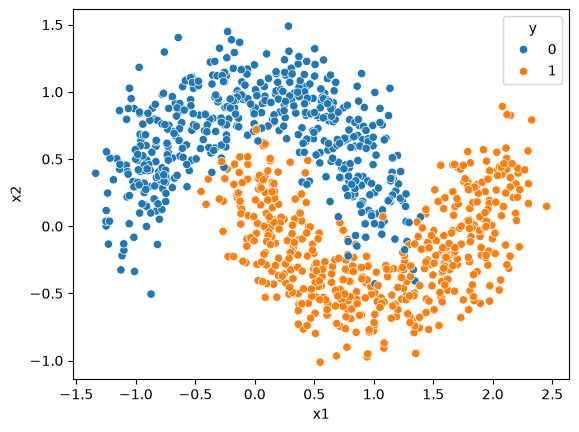

In [5]:
sns.scatterplot(x="x1",y="x2",data=ds,hue="y")
plt.show()

In [6]:
x_a=ds.iloc[:,:-1]
y_a=ds["y"]

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train , y_train , x_test , y_test =train_test_split(x_a ,y_a , test_size=0.2 , random_state=42)

In [9]:
print("Before split:", y.shape)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

print("After split:", y_train.shape)

Before split: (1000,)
After split: (800,)


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [11]:
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
dt.score(x_train , y_train)*100 , dt.score(x_test,y_test)*100

(100.0, 97.5)

In [12]:
sv= SVC()
sv.fit(x_train,y_train)
sv.score(x_train,y_train)*100 , sv.score(x_test,y_test)*100

(97.125, 97.5)

In [13]:
gnb=GaussianNB()
gnb.fit(x_train,y_train)
gnb.score(x_train,y_train)*100 , gnb.score(x_test,y_test)*100

(85.75, 90.0)

In [14]:
from sklearn.ensemble import VotingClassifier

In [15]:
li=[("dt1",DecisionTreeClassifier()),("sv1",SVC()),("gnb1",GaussianNB())]

In [16]:
vc=VotingClassifier(li,weights=[5,4,7])
vc.fit(x_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('dt1', ...), ('sv1', ...), ...]"
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[5, 4, ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[DecisionTreeClassifier(), SVC(), GaussianNB()]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,2


In [17]:
vc.score(x_train,y_train)*100,vc.score(x_test,y_test)*100

(97.625, 97.5)

In [18]:
prd={"dt":dt.predict(x_test),"svm":sv.predict(x_test),"gnb":gnb.predict(x_test),"vc":vc.predict(x_test)}

In [19]:
pd.DataFrame(prd)

,dt,svm,gnb,vc
0,1,1,1,1
1,1,1,1,1
2,0,0,0,0
3,0,0,0,0
4,0,0,1,0
...,...,...,...,...
195,1,1,1,1
196,0,0,0,0
197,1,1,1,1
198,0,0,0,0


# Voting Regresor

In [1]:
import pandas as pd

In [2]:
ds=pd.read_excel("random.csv.xlsx")

In [3]:
ds.head(3)

,CGPA,Score,Salary
0,2.27,68,116201
1,2.39,57,101780
2,2.47,56,108270


In [4]:
x=ds.iloc[:,:-1]
y=ds["Salary"]

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
x_train , x_test , y_train , y_test = train_test_split(x,y,random_state=40,test_size=0.2)

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [8]:
lr=LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_test , y_test)*100 , lr.score(x_train,y_train)*100

(91.6166195611143, 91.06886134831505)

In [9]:
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)
dt.score(x_test,y_test)*100 , dt.score(x_train,y_train)*100

(71.4416150659428, 100.0)

In [10]:
sv=SVR()
sv.fit(x_train,y_train)
sv.score(x_test,y_test)*100 , sv.score(x_train,y_train)*100

(-2.135056652529932, -1.3378987789349317)

In [11]:
from sklearn.ensemble import VotingRegressor

In [12]:
li=[("lr",LinearRegression()),("dt1",DecisionTreeRegressor()),("sv1",SVR())]

In [13]:
vr=VotingRegressor(li)
vr.fit(x_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('dt1', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[LinearRegression(), DecisionTreeRegressor(), SVR()]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['CGPA','Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,2
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'lr': Linear... 'sv1': SVR()}
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True


In [14]:
vr.score(x_train,y_train)*100 , vr.score(x_test,y_test)*100

(85.76323324180221, 77.86826919750463)

# Bagging(Bagging Meta-Estimator , Random Forest)

***1)Bagging Meta-Estimator : base model is Decission Tree but we can change model such as SV,KNN,Beys,etc***
***2)Random Forest : base model is Decission Tree and we can not change these model we work only using Decission treee***

# Bagging Classifer

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons

In [19]:
x,y = make_moons(n_samples=1000,noise=0.2)

In [22]:
df={"x1":x[:,0],"x2":x[:,1],"y":y}

In [23]:
ds=pd.DataFrame(df)

<Axes: xlabel='x1', ylabel='x2'>

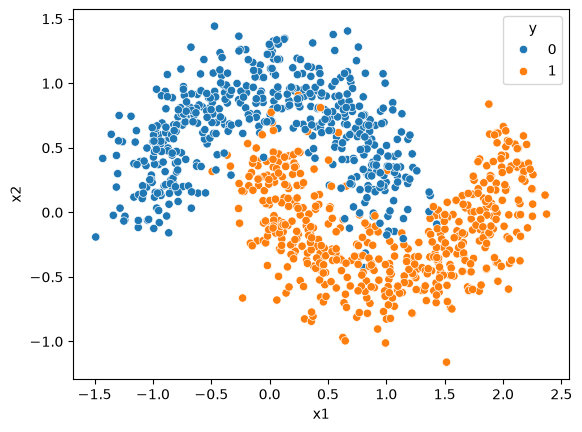

In [24]:
sns.scatterplot(x="x1",y="x2",data=ds,hue="y")

In [25]:
x_a = ds.iloc[:,:-1]
y_a=ds["y"]

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train , x_test , y_train , y_test = train_test_split(x_a , y_a , random_state=42, test_size=0.2)

In [28]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [30]:
sv = SVC()
sv.fit(x_train,y_train)
sv.score(x_test,y_test)*100 , sv.score(x_train,y_train)*100

(98.0, 96.75)

In [31]:
bg=BaggingClassifier(estimator=SVC(),n_estimators=20)
bg.fit(x_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",SVC()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",20
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [32]:
bg.score(x_train,y_train)*100 , bg.score(x_test,y_test)*100


(96.625, 98.0)

In [33]:
rf=RandomForestClassifier(n_estimators=100)
rf.fit(x_train,y_train)
rf.score(x_train,y_train)*100 , rf.score(x_test,y_test)*100

(100.0, 97.5)

# bagging Regrassor

In [1]:
import pandas as pd 

In [2]:
ds = pd.read_excel(r"C:\Users\hp\Desktop\ML 2\regression.csv.xlsx")
ds.head(3)

,Feature,Target
0,1,23
1,2,-7
2,3,-10


In [10]:
x=ds.iloc[:,:1]
y=ds["Target"]

In [4]:
from sklearn.model_selection import train_test_split

In [11]:
x_train , y_train , x_test , y_test = train_test_split(x,y, random_state=42, test_size=0.2)

In [16]:
print("Before split:", y.shape)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

print("After split:", y_train.shape)

Before split: (200,)
After split: (160,)


In [17]:
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
bg=BaggingRegressor(estimator=LinearRegression(),n_estimators=20)
bg.fit(x_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",LinearRegression()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",20
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [20]:
bg.score(x_train,y_train)*100 , bg.score(x_test , y_test)*100

(99.5396537163752, 99.48443543825087)

In [21]:
rf=RandomForestRegressor(n_estimators=100)
rf.fit(x_train,y_train)
rf.score(x_train,y_train)*100 , rf.score(x_test,y_test)*100

(99.89856267120673, 99.25213568920461)